# Reproducing Figures 5(a), 5(b), and 8 (Q-Only Damping, Averaged)

This notebook reproduces paper-style behavior by averaging over deterministic examples.

- Damping mode: **Q messages only** (`DampingEngine`)
- Graph type: **3-variable single cycle**
- Domain size: **2**
- Damping factor: **0.9**
- Examples per experiment: **10**
- Iterations: **50** for Figures 5(a)/5(b), **70** for Figure 8


In [ ]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# walk parents to find the repo root (the directory containing 'experiments/')
cwd = Path.cwd()
repo_root = None
for candidate in [cwd, *cwd.parents]:
    if (candidate / "experiments").is_dir():
        repo_root = candidate
        break
if repo_root is None:
    raise RuntimeError("Could not locate repository root containing 'experiments/'.")

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from experiments.aij.code.utils.fig58_repro import (  # noqa: E402
    CASE_CONSISTENT_NO_TAIL,
    CASE_CONSISTENT_WITH_TAIL,
    CASE_INCONSISTENT_NO_TAIL,
    aggregate_example_records,
    compute_example_slope_summary,
    compute_slope_stats,
    find_cases,
    run_experiment_examples,
)


## Parameters


In [2]:
N_EXAMPLES = 10
SEED_START = 42
SEED_STEP = 1
MAX_ATTEMPTS_PER_SEED = 5000

MAX_ITER_5 = 50
MAX_ITER_8 = 70
DAMPING = 0.9
SLOPE_WINDOW_5 = 20
SLOPE_WINDOW_8 = 20


## Select deterministic examples per experiment

Selection is deterministic first-N pass over seeds (`42, 43, 44, ...`), deduplicated by table triple.


In [3]:
examples_5a = find_cases(
    CASE_CONSISTENT_NO_TAIL,
    n_examples=N_EXAMPLES,
    seed_start=SEED_START,
    seed_step=SEED_STEP,
    max_attempts_per_seed=MAX_ATTEMPTS_PER_SEED,
)
examples_5b = find_cases(
    CASE_CONSISTENT_WITH_TAIL,
    n_examples=N_EXAMPLES,
    seed_start=SEED_START,
    seed_step=SEED_STEP,
    max_attempts_per_seed=MAX_ATTEMPTS_PER_SEED,
)
examples_8 = find_cases(
    CASE_INCONSISTENT_NO_TAIL,
    n_examples=N_EXAMPLES,
    seed_start=SEED_START,
    seed_step=SEED_STEP,
    max_attempts_per_seed=MAX_ATTEMPTS_PER_SEED,
)

print("5(a) selected examples:", [(e["seed"], e["attempt"]) for e in examples_5a])
print("5(b) selected examples:", [(e["seed"], e["attempt"]) for e in examples_5b])
print("8 selected examples:", [(e["seed"], e["attempt"]) for e in examples_8])


5(a) selected examples: [(42, 2), (43, 3), (44, 1), (45, 2), (46, 3), (47, 1), (48, 1), (49, 2), (50, 1), (51, 1)]
5(b) selected examples: [(42, 1), (43, 1), (44, 2), (45, 1), (46, 1), (47, 5), (48, 3), (49, 1), (50, 2), (51, 3)]
8 selected examples: [(42, 72), (43, 60), (44, 114), (45, 103), (46, 16), (47, 141), (48, 60), (49, 159), (50, 300), (51, 131)]


## Run examples and aggregate mean/std


In [4]:
runs_5a = run_experiment_examples(
    examples_5a,
    case_name=CASE_CONSISTENT_NO_TAIL,
    max_iter=MAX_ITER_5,
    damping_factor=DAMPING,
    normalize_messages=False,
    subtract_initial=False,
)
runs_5b = run_experiment_examples(
    examples_5b,
    case_name=CASE_CONSISTENT_WITH_TAIL,
    max_iter=MAX_ITER_5,
    damping_factor=DAMPING,
    normalize_messages=False,
    subtract_initial=False,
)
runs_8 = run_experiment_examples(
    examples_8,
    case_name=CASE_INCONSISTENT_NO_TAIL,
    max_iter=MAX_ITER_8,
    damping_factor=DAMPING,
    normalize_messages=False,
    subtract_initial=False,
)

key_order_5 = ["x1_route", "x2_route", "x3_route"]
key_order_8 = ["x1_v0", "x2_v0", "x3_v0", "x1_v1", "x2_v1", "x3_v1"]

agg_5a = aggregate_example_records(runs_5a, key_order_5)
agg_5b = aggregate_example_records(runs_5b, key_order_5)
agg_8 = aggregate_example_records(runs_8, key_order_8)

print("Aggregated 5(a) examples:", agg_5a["n_examples"])
print("Aggregated 5(b) examples:", agg_5b["n_examples"])
print("Aggregated 8 examples:", agg_8["n_examples"])


Aggregated 5(a) examples: 10
Aggregated 5(b) examples: 10
Aggregated 8 examples: 10


In [5]:
def plot_aggregate(ax, runs, agg, key_order, labels, styles, colors, title, show_band=True):
    iters = np.arange(len(next(iter(agg["mean_records"].values()))))

    # Faint individual traces for context
    for run in runs:
        for key, style, color in zip(key_order, styles, colors):
            y_raw = np.asarray(run["records"][key], dtype=float)
            y_plot = y_raw.copy()
            if y_plot.size:
                y_plot[0] = 0.0  # visualization-only anchor
            ax.plot(iters, y_plot, linestyle=style, color=color, alpha=0.12, linewidth=1.0)

    # Bold mean + optional std band
    for key, label, style, color in zip(key_order, labels, styles, colors):
        mean = np.asarray(agg["mean_records"][key], dtype=float)
        std = np.asarray(agg["std_records"][key], dtype=float)

        y_plot = mean.copy()
        if y_plot.size:
            y_plot[0] = 0.0  # visualization-only anchor
        ax.plot(iters, y_plot, linestyle=style, color=color, linewidth=2.2, label=label)

        if show_band:
            upper = mean + std
            lower = mean - std
            if upper.size:
                upper = upper.copy(); upper[0] = 0.0
                lower = lower.copy(); lower[0] = 0.0
            ax.fill_between(iters, lower, upper, color=color, alpha=0.14)

    ax.set_xlabel("Iteration")
    ax.set_ylabel("Value")
    ax.set_title(title)
    ax.legend(loc="best", fontsize=9)


## Figures 5(a) and 5(b) together

Each plot is averaged over 10 deterministic examples.
- Faint lines: individual examples.
- Bold lines: mean traces.
- Shaded area: ±1 std.
- First shown point is forced to zero for visual alignment only.


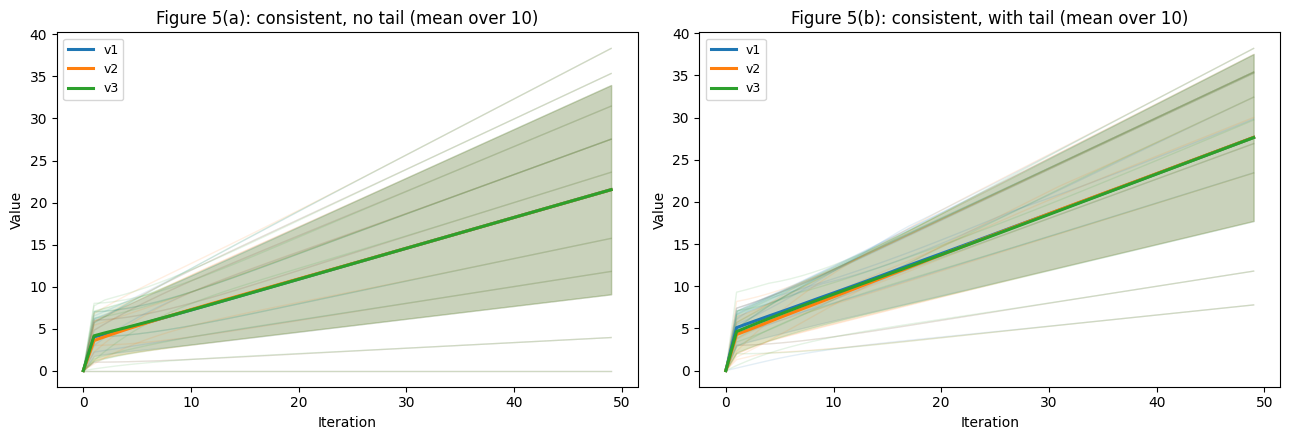

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

plot_aggregate(
    axes[0],
    runs_5a,
    agg_5a,
    key_order_5,
    labels=["v1", "v2", "v3"],
    styles=["-", "-", "-"],
    colors=["tab:blue", "tab:orange", "tab:green"],
    title="Figure 5(a): consistent, no tail (mean over 10)",
)
plot_aggregate(
    axes[1],
    runs_5b,
    agg_5b,
    key_order_5,
    labels=["v1", "v2", "v3"],
    styles=["-", "-", "-"],
    colors=["tab:blue", "tab:orange", "tab:green"],
    title="Figure 5(b): consistent, with tail (mean over 10)",
)

plt.tight_layout()
plt.show()


## Figure 5(a) alone

This isolates the **consistent, no-tail** regime.
- All three variable-role routes grow with near-matching long-run slope.
- Faint lines are the 10 deterministic examples; bold lines are pointwise means.
- The first shown point is forced to `(0,0)` for visual alignment only.


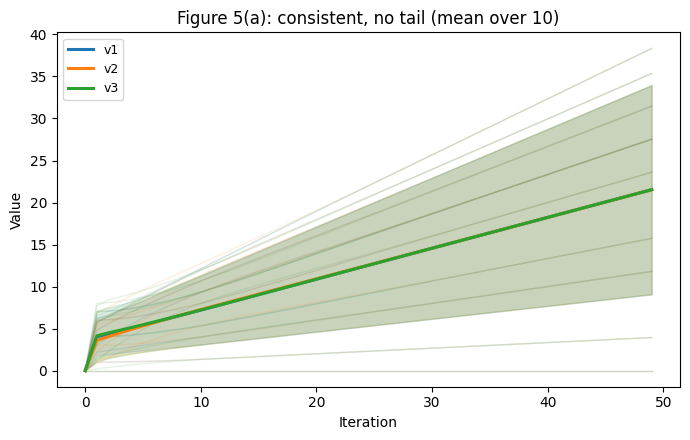

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5))
plot_aggregate(
    ax,
    runs_5a,
    agg_5a,
    key_order_5,
    labels=["v1", "v2", "v3"],
    styles=["-", "-", "-"],
    colors=["tab:blue", "tab:orange", "tab:green"],
    title="Figure 5(a): consistent, no tail (mean over 10)",
)
plt.tight_layout()
plt.show()


## Figure 5(b) alone

This isolates the **consistent, with-tail** regime.
- Early-iteration separation reflects transient tail behavior before the periodic route dominates.
- Faint lines are the 10 deterministic examples; bold lines are pointwise means.
- The first shown point is forced to `(0,0)` for visual alignment only.


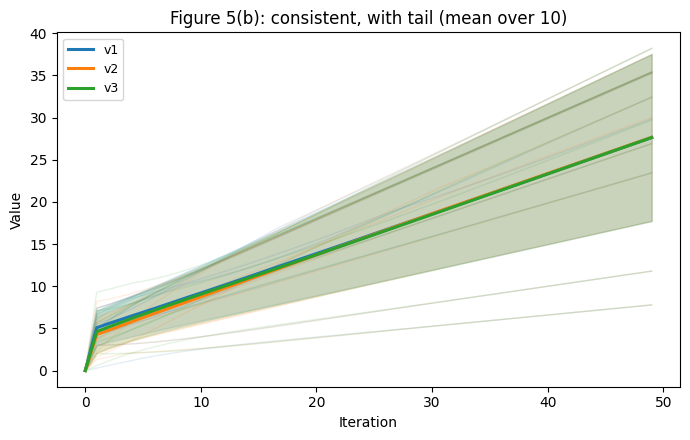

In [8]:
fig, ax = plt.subplots(figsize=(7, 4.5))
plot_aggregate(
    ax,
    runs_5b,
    agg_5b,
    key_order_5,
    labels=["v1", "v2", "v3"],
    styles=["-", "-", "-"],
    colors=["tab:blue", "tab:orange", "tab:green"],
    title="Figure 5(b): consistent, with tail (mean over 10)",
)
plt.tight_layout()
plt.show()


## Figure 8 alone

This isolates the **inconsistent, no-tail** regime.
- Each variable is tracked on both domain values (`v0` and `v1`) to expose competing routes.
- Faint lines are the 10 deterministic examples; bold lines are pointwise means.
- The first shown point is forced to `(0,0)` for visual alignment only.


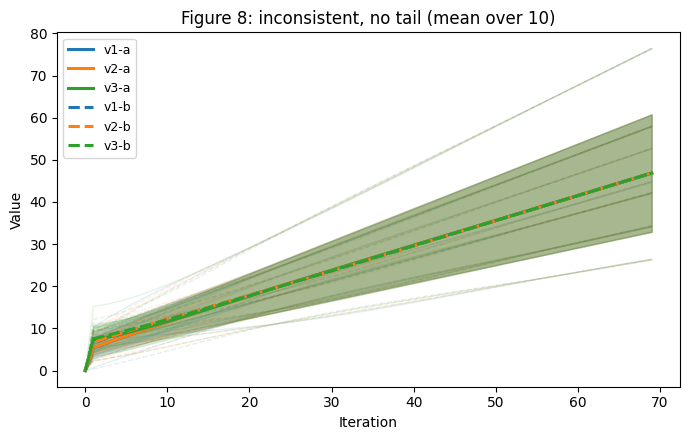

In [9]:
fig, ax = plt.subplots(figsize=(7, 4.5))
plot_aggregate(
    ax,
    runs_8,
    agg_8,
    key_order_8,
    labels=["v1-a", "v2-a", "v3-a", "v1-b", "v2-b", "v3-b"],
    styles=["-", "-", "-", "--", "--", "--"],
    colors=["tab:blue", "tab:orange", "tab:green", "tab:blue", "tab:orange", "tab:green"],
    title="Figure 8: inconsistent, no tail (mean over 10)",
)
plt.tight_layout()
plt.show()


## Slope checks on mean traces (last 20 iterations)


In [10]:
stats_5a_mean = compute_slope_stats(
    agg_5a["mean_records"],
    MAX_ITER_5 - SLOPE_WINDOW_5,
    MAX_ITER_5,
)
stats_5b_mean = compute_slope_stats(
    agg_5b["mean_records"],
    MAX_ITER_5 - SLOPE_WINDOW_5,
    MAX_ITER_5,
)
stats_8_mean = compute_slope_stats(
    agg_8["mean_records"],
    MAX_ITER_8 - SLOPE_WINDOW_8,
    MAX_ITER_8,
)

print("5(a) mean slopes:")
for k, v in stats_5a_mean["slopes"].items():
    print(f"  {k}: {v:.6f}")
print(f"  relative spread: {stats_5a_mean['relative_spread_percent']:.4f}%")

print()
print("5(b) mean slopes:")
for k, v in stats_5b_mean["slopes"].items():
    print(f"  {k}: {v:.6f}")
print(f"  relative spread: {stats_5b_mean['relative_spread_percent']:.4f}%")

print()
print("8 mean slopes:")
for k, v in stats_8_mean["slopes"].items():
    print(f"  {k}: {v:.6f}")
print(f"  relative spread: {stats_8_mean['relative_spread_percent']:.4f}%")


5(a) mean slopes:
  x1_route: 0.366720
  x2_route: 0.366465
  x3_route: 0.366815
  relative spread: 0.0956%

5(b) mean slopes:
  x1_route: 0.476922
  x2_route: 0.476387
  x3_route: 0.479785
  relative spread: 0.7113%

8 mean slopes:
  x1_v0: 0.590847
  x2_v0: 0.590581
  x3_v0: 0.591258
  x1_v1: 0.595845
  x2_v1: 0.596104
  x3_v1: 0.595365
  relative spread: 0.9308%


## Final tables

Table A: side-by-side **mean traces** by iteration.  
Table B: **per-example slope summary**.

Both tables are computed from raw traces (no subtract-initial and no visual anchor mutation).


In [11]:
def _df_from_records(records, column_map, n_rows):
    df = pd.DataFrame({
        label: pd.Series(records[key])
        for key, label in column_map
    })
    return df.reindex(range(n_rows))

n_rows = max(MAX_ITER_5, MAX_ITER_8)

df_5a_mean = _df_from_records(
    agg_5a["mean_records"],
    [("x1_route", "v1"), ("x2_route", "v2"), ("x3_route", "v3")],
    n_rows,
)
df_5b_mean = _df_from_records(
    agg_5b["mean_records"],
    [("x1_route", "v1"), ("x2_route", "v2"), ("x3_route", "v3")],
    n_rows,
)
df_8_mean = _df_from_records(
    agg_8["mean_records"],
    [
        ("x1_v0", "v1-a"), ("x2_v0", "v2-a"), ("x3_v0", "v3-a"),
        ("x1_v1", "v1-b"), ("x2_v1", "v2-b"), ("x3_v1", "v3-b"),
    ],
    n_rows,
)

mean_trace_table = pd.concat(
    {"Figure 5(a) mean": df_5a_mean, "Figure 5(b) mean": df_5b_mean, "Figure 8 mean": df_8_mean},
    axis=1,
)
mean_trace_table.index.name = "iteration"

display(mean_trace_table)

slope_summary = pd.concat(
    [
        compute_example_slope_summary(runs_5a, MAX_ITER_5 - SLOPE_WINDOW_5, MAX_ITER_5),
        compute_example_slope_summary(runs_5b, MAX_ITER_5 - SLOPE_WINDOW_5, MAX_ITER_5),
        compute_example_slope_summary(runs_8, MAX_ITER_8 - SLOPE_WINDOW_8, MAX_ITER_8),
    ],
    ignore_index=True,
)

display(slope_summary)


Figure 5(a) mean                   Figure 5(b) mean           \
                        v1       v2       v3               v1       v2   
iteration                                                                
0                  3.70000  3.10000  3.80000          4.60000  3.80000   
1                  4.02000  3.58000  4.14000          5.09000  4.28000   
2                  4.35300  4.03900  4.48800          5.57100  4.77300   
3                  4.69690  4.48030  4.80730          6.02160  5.27690   
4                  5.04629  4.90684  5.13137          6.47745  5.78179   
...                    ...      ...      ...              ...      ...   
65                     NaN      NaN      NaN              NaN      NaN   
66                     NaN      NaN      NaN              NaN      NaN   
67                     NaN      NaN      NaN              NaN      NaN   
68                     NaN      NaN      NaN              NaN      NaN   
69                     NaN      NaN      NaN              NaN      NaN   

                   Figure 8 mean                                              \
                v3          v1-a       v2-a       v3-a       v1-b       v2-b   
iteration                                                                      
0          4.10000      4.600000   4.700000   7.000000   5.900000   6.000000   
1          4.63000      5.360000   5.440000   7.310000   6.580000   6.680000   
2          5.15200      6.102000   6.163000   7.666000   7.244000   7.344000   
3          5.66810      6.827400   6.870700   8.063200   7.894000   7.993800   
4          6.17689      7.537700   7.564790   8.496920   8.531910   8.631180   
...            ...           ...        ...        ...        ...        ...   
65             NaN     44.468703  44.474936  44.480586  44.506534  44.500313   
66             NaN     45.061187  45.067337  45.073138  45.100726  45.094585   
67             NaN     45.653905  45.659998  45.665880  45.694682  45.688597   
68             NaN     46.246843  46.252902  46.258801  46.288418  46.282364   
69             NaN     46.839983  46.846031  46.851887  46.881950  46.875906   

                      
                v3-b  
iteration             
0           7.100000  
1           7.550000  
2           8.025000  
3           8.522400  
4           9.007070  
...              ...  
65         44.494760  
66         45.088857  
67         45.682767  
68         46.276502  
69         46.870074  

[70 rows x 12 columns]

,experiment,example_index,seed,attempt,series_key,slope,example_relative_spread_percent
0,consistent_no_tail,0,42,2,x1_route,0.200000,0.438347
1,consistent_no_tail,0,42,2,x2_route,0.200438,0.438347
2,consistent_no_tail,0,42,2,x3_route,0.199562,0.438347
3,consistent_no_tail,1,43,3,x1_route,0.532749,0.328760
4,consistent_no_tail,1,43,3,x2_route,0.532749,0.328760
...,...,...,...,...,...,...,...
115,inconsistent_no_tail,9,51,131,x1_v1,0.544720,7.468637
116,inconsistent_no_tail,9,51,131,x2_v0,0.513414,7.468637
117,inconsistent_no_tail,9,51,131,x2_v1,0.553247,7.468637
118,inconsistent_no_tail,9,51,131,x3_v0,0.524795,7.468637
